Cells: 2974
IsoCAPE sites: 153156
IsoDecipher features: 63825

Cell types:
cell_type
Tumor_Luminal           948
Tumor_DNAstress         519
Tumor_RGS5high          491
Tumor_heatshock         437
Macrophage              201
Tumor_Neuroendocrine    139
Tumor_Proliferating      59
Tumor_LuminalA           54
Fibroblast               51
Endothelial              46
Smooth_muscle            29
Name: count, dtype: int64


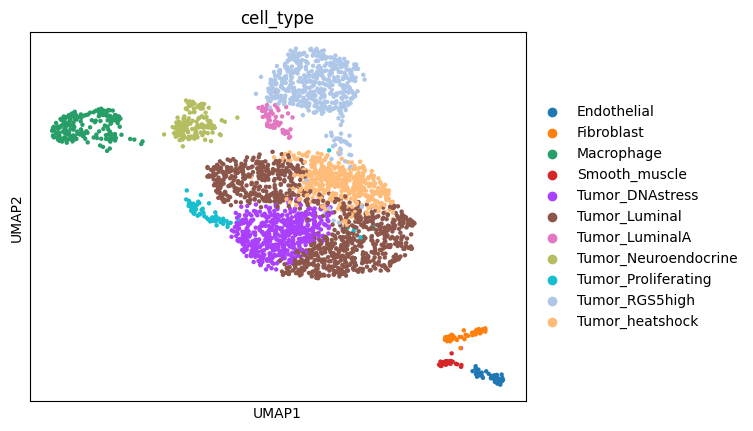

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Read annotated object
adata_gex = sc.read_h5ad('/Users/renegibson/Downloads/IDC_gex_annotated.h5ad')

cape_feat = adata_gex.uns['isocape_features']
iso_feat  = adata_gex.uns['isoform_features']

print(f"Cells: {adata_gex.n_obs}")
print(f"IsoCAPE sites: {len(cape_feat)}")
print(f"IsoDecipher features: {len(iso_feat)}")
print(f"\nCell types:")
print(adata_gex.obs['cell_type'].value_counts())

sc.pl.umap(adata_gex, color='cell_type')

Tumor clusters: 9


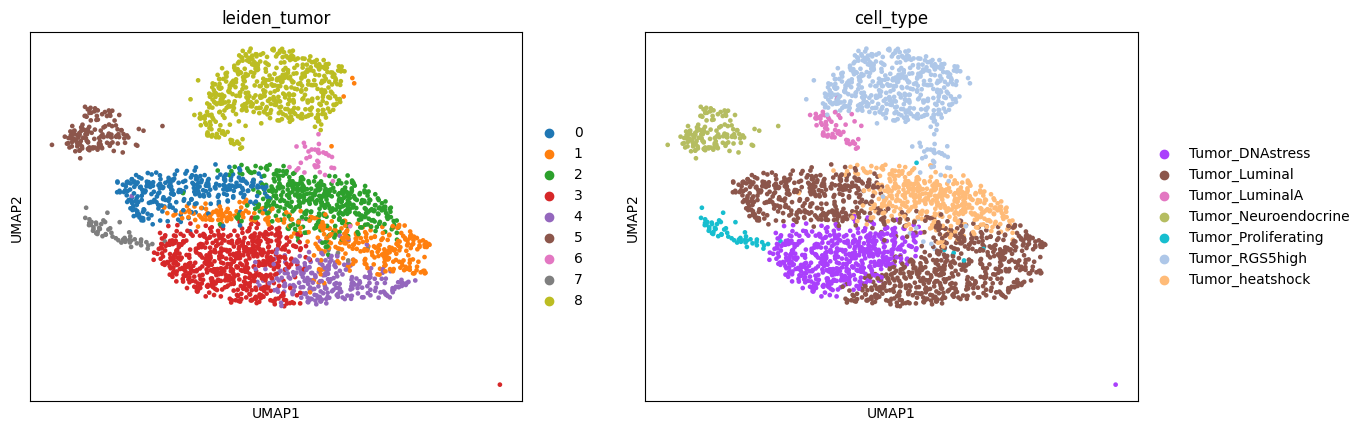

In [129]:
import scanpy as sc

# 只看tumor cells
tumor_mask = adata_gex.obs['cell_type'].str.startswith('Tumor').values
adata_tumor = adata_gex[tumor_mask].copy()

# 重新跑higher resolution leiden
sc.tl.leiden(adata_tumor, resolution=0.7,
             flavor='igraph', directed=False, n_iterations=2,
             key_added='leiden_tumor')

print(f"Tumor clusters: {adata_tumor.obs['leiden_tumor'].nunique()}")

sc.pl.umap(adata_tumor, 
           color=['leiden_tumor', 'cell_type'],
           ncols=2)

In [130]:
sc.tl.rank_genes_groups(
    adata_tumor,
    groupby='leiden_tumor',
    method='wilcoxon',
    use_raw=True,
    n_genes=10
)

# Print top markers per cluster
result = adata_tumor.uns['rank_genes_groups']
for group in result['names'].dtype.names:
    names = result['names'][group][:8]
    logfc = result['logfoldchanges'][group][:8]
    print(f"\nCluster {group}:")
    for n, l in zip(names, logfc):
        print(f"  {n}: logFC={l:.2f}")


Cluster 0:
  APOD: logFC=0.91
  TMEM47: logFC=1.26
  MT-ND4L: logFC=0.73
  IGFBP2: logFC=0.88
  AZGP1: logFC=0.64
  PIP: logFC=1.99
  MGP: logFC=2.10
  TRPA1: logFC=0.91

Cluster 1:
  TFF1: logFC=3.13
  TFF3: logFC=2.72
  CHGB: logFC=2.01
  HSPA6: logFC=2.07
  CXCL14: logFC=2.48
  IGFBP2: logFC=0.84
  DDIT4: logFC=1.51
  SERPINA6: logFC=1.11

Cluster 2:
  DNAJB1: logFC=1.78
  HSPA1B: logFC=1.60
  HSPA1A: logFC=1.56
  HSP90AA1: logFC=1.29
  ZFAND2A: logFC=2.36
  HSPA6: logFC=2.72
  DNAJA1: logFC=1.28
  UBB: logFC=1.20

Cluster 3:
  JUND: logFC=1.00
  ELF3: logFC=1.45
  TM4SF1: logFC=1.33
  KLF6: logFC=1.57
  CLDN4: logFC=1.19
  GADD45A: logFC=1.36
  ATF4: logFC=0.94
  MAP3K8: logFC=1.41

Cluster 4:
  CXCL14: logFC=4.46
  CHGB: logFC=1.99
  LTF: logFC=1.61
  RPS7: logFC=0.59
  RPS8: logFC=0.65
  RPL11: logFC=0.63
  RPL18A: logFC=0.64
  KRT23: logFC=0.97

Cluster 5:
  IGSF1: logFC=6.49
  SLC30A8: logFC=3.97
  RAMP3: logFC=2.78
  RAMP1: logFC=4.58
  CLEC3A: logFC=2.06
  DNAJC19: logFC=1.5

tumor_subtype
Tumor_DNAstress         598
Tumor_RGS5_BASP1        506
Tumor_HeatShock         441
Tumor_Luminal           336
Tumor_Lipid             291
Tumor_CXCL14            242
Tumor_Neuroendocrine    139
Tumor_Proliferating      58
Tumor_RGS5high           36
Name: count, dtype: int64


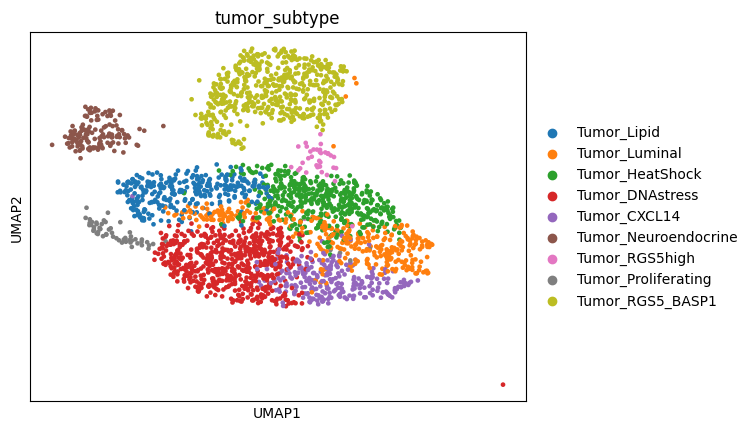

In [131]:
tumor_type_map = {
    '0':  'Tumor_Lipid',           # APOD, AZGP1, PIP, MGP → lipid metabolism
    '1':  'Tumor_Luminal',         # TFF1/3, CHGB, CXCL14
    '2':  'Tumor_HeatShock',       # HSPA1A/B, HSP90AA1, DNAJB1
    '3':  'Tumor_DNAstress',       # GADD45A, JUND, ELF3, ATF4
    '4':  'Tumor_CXCL14',          # CXCL14高, CHGB, LTF, ribosomal
    '5':  'Tumor_Neuroendocrine',  # IGSF1, SLC30A8, NTS, RAMP1/3
    '6':  'Tumor_RGS5high',        # RGS5, GATA3, HOMER1
    '7':  'Tumor_Proliferating',   # MKI67, STMN1, BIRC5, CENPF
    '8':  'Tumor_RGS5_BASP1',      # RGS5+BASP1, EPHX1, CRABP2
}

adata_tumor.obs['tumor_subtype'] = adata_tumor.obs['leiden_tumor'].map(tumor_type_map)

print(adata_tumor.obs['tumor_subtype'].value_counts())
sc.pl.umap(adata_tumor, color='tumor_subtype')

cell_type_detailed
Tumor_DNAstress         598
Tumor_RGS5_BASP1        506
Tumor_HeatShock         441
Tumor_Luminal           336
Tumor_Lipid             291
Tumor_CXCL14            242
Macrophage              201
Tumor_Neuroendocrine    139
Tumor_Proliferating      58
Fibroblast               51
Endothelial              46
Tumor_RGS5high           36
Smooth_muscle            29
Name: count, dtype: int64


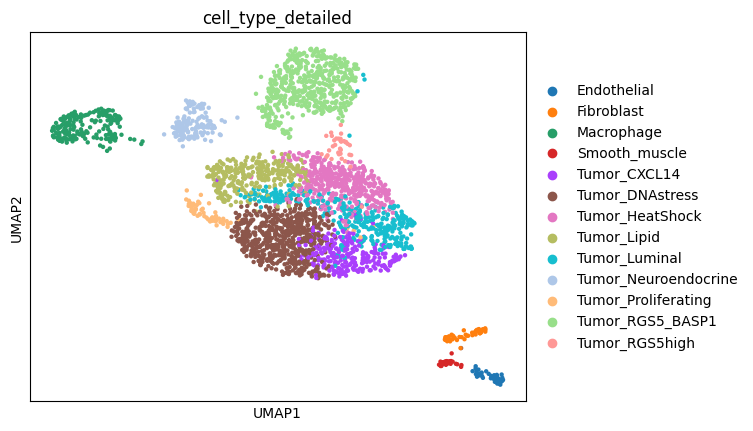

cell_type_detailed
Tumor_DNAstress         598
Tumor_RGS5_BASP1        506
Tumor_HeatShock         441
Tumor_Luminal           336
Tumor_Lipid             291
Tumor_CXCL14            242
Macrophage              201
Tumor_Neuroendocrine    139
Stromal                 126
Tumor_Proliferating      58
Tumor_RGS5high           36
Name: count, dtype: int64


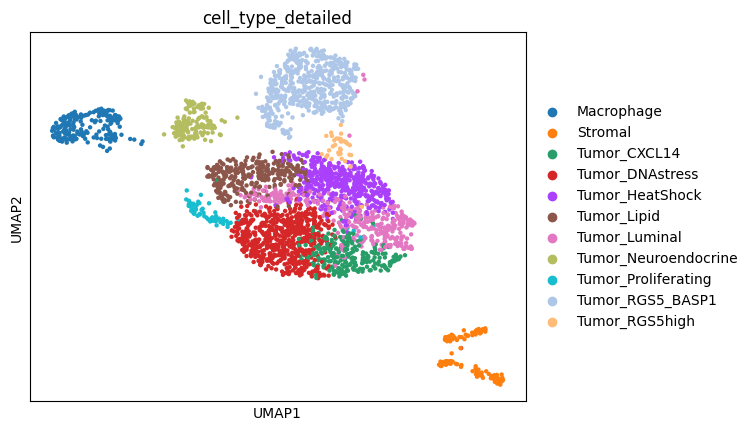

In [136]:
# 把tumor subtype加回adata_gex
adata_gex.obs['cell_type_detailed'] = adata_gex.obs['cell_type'].astype(str)

tumor_obs_names = adata_tumor.obs_names
for cell, subtype in zip(tumor_obs_names, 
                          adata_tumor.obs['tumor_subtype'].values):
    adata_gex.obs.loc[cell, 'cell_type_detailed'] = subtype

print(adata_gex.obs['cell_type_detailed'].value_counts())
sc.pl.umap(adata_gex, color='cell_type_detailed')
# Simplify non-tumor cells
simplify = {
    'Endothelial':  'Stromal',
    'Fibroblast':   'Stromal',
    'Smooth_muscle':'Stromal',
}

adata_gex.obs['cell_type_detailed'] = adata_gex.obs['cell_type'].astype(str)

# Simplify stromal
for ct, simple in simplify.items():
    mask = adata_gex.obs['cell_type'] == ct
    adata_gex.obs.loc[mask, 'cell_type_detailed'] = simple

# Update tumor cells
for cell, subtype in zip(adata_tumor.obs_names,
                          adata_tumor.obs['tumor_subtype'].values):
    adata_gex.obs.loc[cell, 'cell_type_detailed'] = subtype

print(adata_gex.obs['cell_type_detailed'].value_counts())
sc.pl.umap(adata_gex, color='cell_type_detailed')


In [2]:

from collections import defaultdict

cape_var = pd.DataFrame(adata_gex.uns['isocape_var'])
cape_feat = adata_gex.uns['isocape_features']

# indexing
gene_ce = defaultdict(list)
gene_pa = defaultdict(list)
gene_kn = defaultdict(list)

for i, site in enumerate(cape_feat):
    gene = cape_var.loc[site, 'gene']
    st   = cape_var.loc[site, 'site_type']
    if st == 'CE':
        gene_ce[gene].append(i)
    elif st in ('PA', 'PA_validated', 'PA_novel'):
        gene_pa[gene].append(i)
    elif st == 'known':
        gene_kn[gene].append(i)

# CE fraction
isocape_mat = adata_gex.obsm['isocape']
gene_fracs  = {}

for gene in gene_ce:
    ce_idx = gene_ce[gene]
    pa_idx = gene_pa.get(gene, [])
    kn_idx = gene_kn.get(gene, [])

    ce_total = float(isocape_mat[:, ce_idx].sum())
    pa_total = float(isocape_mat[:, pa_idx].sum()) if pa_idx else 0
    kn_total = float(isocape_mat[:, kn_idx].sum()) if kn_idx else 0

    total = ce_total + pa_total + kn_total
    if total >= 10 and ce_total >= 5:
        gene_fracs[gene] = {
            'ce_fraction': ce_total / total,
            'ce_reads':    ce_total,
            'total_reads': total,
        }

frac_df = pd.DataFrame(gene_fracs).T.sort_values('ce_fraction', ascending=False)


All genes with CE: 1787
Reliable (CE≥50, total≥200): 538
          ce_fraction  ce_reads  total_reads
DPM2            0.962     229.0        238.0
MXD4            0.952     377.0        396.0
NCKAP5L         0.910     183.0        201.0
SCAMP4          0.902     440.0        488.0
NBEAL1          0.766     383.0        500.0
ITFG2           0.759     268.0        353.0
DNAAF1          0.737     473.0        642.0
GGA1            0.732     230.0        314.0
CES4A           0.655     205.0        313.0
FUS             0.651    2618.0       4019.0
HPS4            0.651     267.0        410.0
FHIT            0.614     420.0        684.0
SF1             0.568    3817.0       6724.0
NEIL1           0.566     125.0        221.0
STK4            0.564     232.0        411.0
TOP3A           0.563     210.0        373.0
RBM6            0.544     698.0       1283.0
BCAM            0.542     285.0        526.0
PKNOX1          0.498     124.0        249.0
CASP8           0.492     174.0        354.

In [3]:

# Reliable filter
reliable = frac_df[
    (frac_df['ce_reads'] >= 50) 
].sort_values('ce_fraction', ascending=False)

print(f"All genes with CE: {len(frac_df)}")
print(f"Reliable (CE≥50): {len(reliable)}")
print(reliable.head(50).round(3))


All genes with CE: 1787
Reliable (CE≥50): 573
         ce_fraction  ce_reads  total_reads
ATG2A          0.984     190.0        193.0
PCSK7          0.966     140.0        145.0
DPM2           0.962     229.0        238.0
SMARCD3        0.960     170.0        177.0
MXD4           0.952     377.0        396.0
TNK2           0.941     111.0        118.0
RGS11          0.929     105.0        113.0
TSC22D4        0.920      92.0        100.0
NCKAP5L        0.910     183.0        201.0
NAT9           0.903     159.0        176.0
SCAMP4         0.902     440.0        488.0
PRR3           0.883     144.0        163.0
MAP3K11        0.863     107.0        124.0
RAD9A          0.846      99.0        117.0
EIF2B4         0.815     101.0        124.0
NBEAL1         0.766     383.0        500.0
ITFG2          0.759     268.0        353.0
DNAAF1         0.737     473.0        642.0
PHLDB1         0.736      53.0         72.0
GGA1           0.732     230.0        314.0
ZNF224         0.714     120.0

In [137]:
# 用新的cell_type_detailed更新masks
mac_mask      = (adata_gex.obs['cell_type_detailed'] == 'Macrophage').values
stromal_mask  = (adata_gex.obs['cell_type_detailed'] == 'Stromal').values
nontumor_mask = mac_mask | stromal_mask
tumor_mask    = adata_gex.obs['cell_type_detailed'].str.startswith('Tumor').values

print(f"Macrophage:  {mac_mask.sum()} cells")
print(f"Stromal:     {stromal_mask.sum()} cells")
print(f"Non-tumor:   {nontumor_mask.sum()} cells")
print(f"Tumor:       {tumor_mask.sum()} cells")
print(f"\nCell type breakdown:")
print(adata_gex.obs['cell_type_detailed'].value_counts())
# BC genes of interest
bc_genes = [
    'DNAAF1', 'MXD4', 'FHIT', 'CASP8',
    'NFKB2', 'STK4', 'MAP2K7', 'DOT1L',
    'PKNOX1', 'DAZAP2', 'KMT5C', 'TOP3A',
    'NEIL1', 'BCAM', 'RBM6', 'FUS', 'SF1',
]

print(f"\nBC genes to analyze: {bc_genes}")

# Per-site CE fraction analysis
print("\nPer-site CE fraction: Non-tumor vs Tumor\n")
for gene in bc_genes:
    ce_idx_list = gene_ce.get(gene, [])
    if not ce_idx_list:
        continue
    
    print(f"\n{'='*65}")
    print(f"{gene}")
    print(f"{'Site':<28} {'non-tumor':>10} {'tumor':>8} {'delta':>7} {'reads':>7}")
    print(f"{'-'*65}")
    
    pa_idx = gene_pa.get(gene, [])
    kn_idx = gene_kn.get(gene, [])
    
    for i in ce_idx_list:
        site  = cape_feat_list[i]
        coord = cape_var_df.loc[site, 'rep_coord']
        reads = float(isocape_mat[:, i].sum())
        if reads < 20:
            continue
        
        def site_frac(mask):
            ce = float(isocape_mat[mask, i].sum())
            pa = float(isocape_mat[mask][:,pa_idx].sum()) if pa_idx else 0
            kn = float(isocape_mat[mask][:,kn_idx].sum()) if kn_idx else 0
            t  = ce + pa + kn
            return ce/t if t > 0 else 0
        
        nt_f    = site_frac(nontumor_mask)
        tumor_f = site_frac(tumor_mask)
        delta   = tumor_f - nt_f
        flag    = '✅' if delta > 0.10 else '⚠️' if delta > 0.03 else '❌'
        
        print(f"  {coord:<26} {nt_f:>10.3f} {tumor_f:>8.3f} "
              f"{delta:>7.3f} {flag} ({reads:.0f})")

Macrophage:  201 cells
Stromal:     126 cells
Non-tumor:   327 cells
Tumor:       2647 cells

Cell type breakdown:
cell_type_detailed
Tumor_DNAstress         598
Tumor_RGS5_BASP1        506
Tumor_HeatShock         441
Tumor_Luminal           336
Tumor_Lipid             291
Tumor_CXCL14            242
Macrophage              201
Tumor_Neuroendocrine    139
Stromal                 126
Tumor_Proliferating      58
Tumor_RGS5high           36
Name: count, dtype: int64

BC genes to analyze: ['DNAAF1', 'MXD4', 'FHIT', 'CASP8', 'NFKB2', 'STK4', 'MAP2K7', 'DOT1L', 'PKNOX1', 'DAZAP2', 'KMT5C', 'TOP3A', 'NEIL1', 'BCAM', 'RBM6', 'FUS', 'SF1']

Per-site CE fraction: Non-tumor vs Tumor


DNAAF1
Site                          non-tumor    tumor   delta   reads
-----------------------------------------------------------------
  84173338                        0.000    0.492   0.492 ✅ (160)
  84173579                        0.000    0.413   0.413 ✅ (116)
  84173725                        0.200    0.425 

In [121]:
# 在IDC dataset裡DNAAF1的expression
dnaaf1_gex = adata_gex[:, 'DNAAF1'].X.toarray().flatten()
print("DNAAF1 GEX by cell type:")
for ct in sorted(adata_gex.obs['cell_type'].unique()):
    mask = (adata_gex.obs['cell_type']==ct).values
    mean = dnaaf1_gex[mask].mean()
    pos  = (dnaaf1_gex[mask]>0).sum()
    print(f"  {ct:<25}: mean={mean:.3f}, cells={pos}/{mask.sum()}")

DNAAF1 GEX by cell type:
  Endothelial              : mean=0.000, cells=0/46
  Fibroblast               : mean=0.022, cells=4/51
  Macrophage               : mean=0.055, cells=10/201
  Smooth_muscle            : mean=0.000, cells=0/29
  Tumor_DNAstress          : mean=0.298, cells=350/519
  Tumor_Luminal            : mean=0.269, cells=583/948
  Tumor_LuminalA           : mean=0.166, cells=24/54
  Tumor_Neuroendocrine     : mean=0.108, cells=44/139
  Tumor_Proliferating      : mean=0.156, cells=30/59
  Tumor_RGS5high           : mean=0.155, cells=180/491
  Tumor_heatshock          : mean=0.299, cells=291/437


In [122]:
import gffutils
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

db = gffutils.FeatureDB(
    '/Users/renegibson/Desktop/githubrepo/IsoDecipher/data/Homo_sapiens.GRCh38.115.gtf.db'
)

# MXD4 gene info
genes_mx = [g for g in db.features_of_type('gene')
            if g.attributes.get('gene_name',[''])[0]=='MXD4']
gx = genes_mx[0]
print(f"MXD4: {gx.chrom}:{gx.start}-{gx.end} ({gx.strand})")

# 主要transcript
best_tx, best_n = None, 0
for tx in db.children(gx, featuretype='transcript'):
    if tx.attributes.get('transcript_biotype',[''])[0]!='protein_coding':
        continue
    n = len(list(db.children(tx, featuretype='exon')))
    if n > best_n:
        best_n, best_tx = n, tx

exons = sorted(db.children(best_tx, featuretype='exon'),
               key=lambda e: e.start)
n_exons = len(exons)
print(f"Transcript: {best_tx.id}, {n_exons} exons")

# transcript order（-strand）
for i, exon in enumerate(exons):
    tx_num = n_exons - i
    print(f"  Exon {tx_num}: {exon.start}-{exon.end} ({exon.end-exon.start}bp)")

# CE sites
print(f"\nCE sites:")
for i in gene_ce.get('MXD4',[]):
    site  = cape_feat_list[i]
    coord = int(cape_var_df.loc[site,'rep_coord'])
    reads = float(isocape_mat[:,i].sum())
    pas   = cape_var_df.loc[site,'pas_signal']
    print(f"  {coord}: reads={reads:.0f}, PAS={pas}")

# IsoDecipher
panel = pd.read_csv(
    '/Users/renegibson/Desktop/githubrepo/IsoDecipher/results/panel_features_IDC.csv',
    low_memory=False
)
mxd4_panel = panel[panel['gene']=='MXD4'][
    ['polyA_group','rep_coord','avg_spliced_utr','utr_source']
].sort_values('rep_coord')
print(f"\nMXD4 IsoDecipher G-groups:")
print(mxd4_panel)

MXD4: 4:2247432-2262115 (-)
Transcript: ENST00000337190, 6 exons
  Exon 6: 2247432-2250701 (3269bp)
  Exon 5: 2251084-2251246 (162bp)
  Exon 4: 2252408-2252522 (114bp)
  Exon 3: 2257982-2258011 (29bp)
  Exon 2: 2261725-2261824 (99bp)
  Exon 1: 2261917-2262109 (192bp)

CE sites:
  2254615: reads=305, PAS=AATATA
  2254737: reads=72, PAS=AACAAA

MXD4 IsoDecipher G-groups:
       polyA_group  rep_coord  avg_spliced_utr      utr_source
36817            4    2247432           3115.0  protein_coding
36816            3    2247443           3104.0  protein_coding
36815            2    2249450           1097.0  protein_coding
36814            1    2250231            316.0  protein_coding
36813            0    2250658              0.0      non_coding


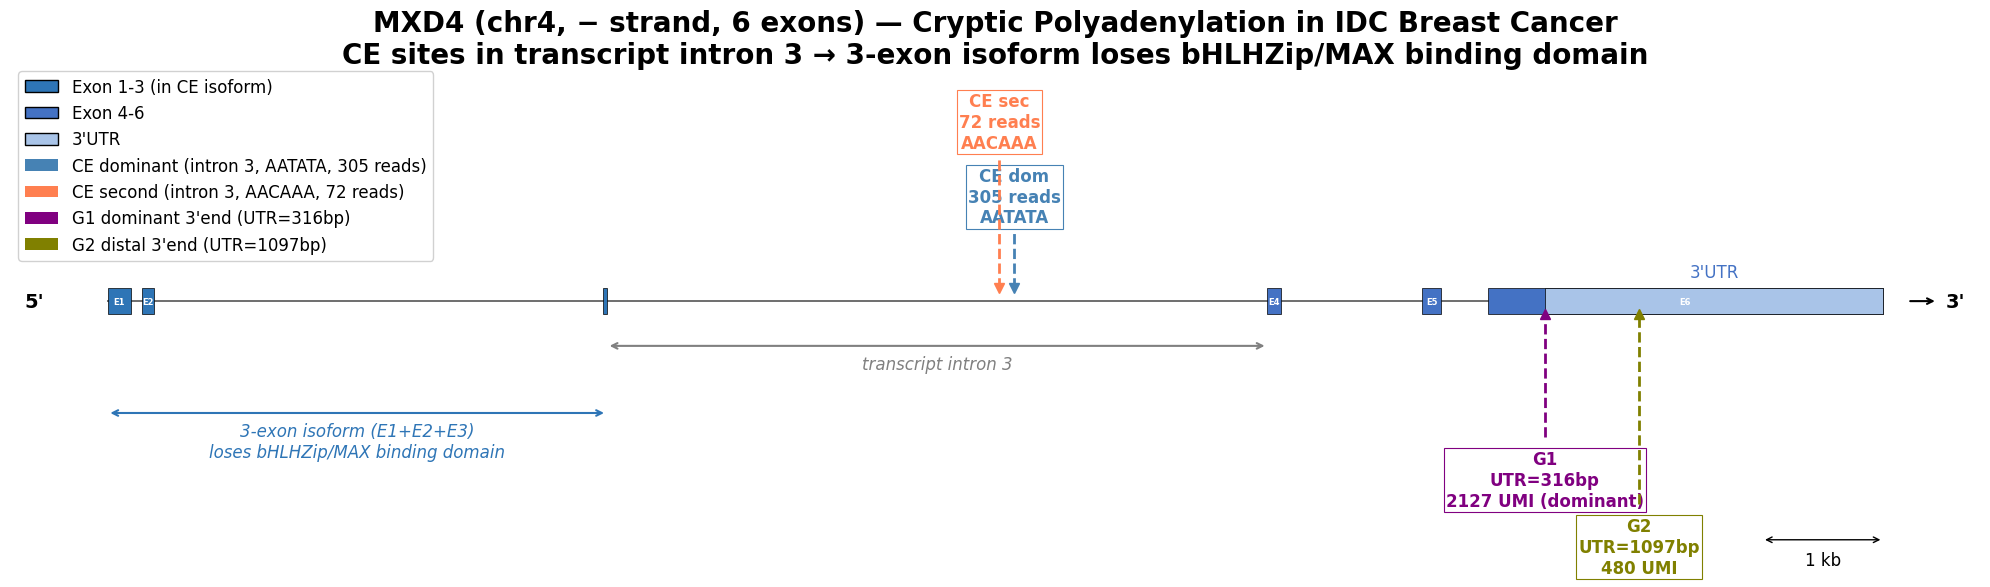

Saved!


In [159]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# MXD4 gene info
gene_start = 2247432
gene_end   = 2262115
gene_len   = gene_end - gene_start
strand     = '-'

def to_plot(coord):
    return gene_end - coord  # flip for - strand

# Exons (transcript order, already provided)
exons_data = [
    (2261917, 2262109, 'E1'),  # Exon 1
    (2261725, 2261824, 'E2'),  # Exon 2
    (2257982, 2258011, 'E3'),  # Exon 3
    (2252408, 2252522, 'E4'),  # Exon 4
    (2251084, 2251246, 'E5'),  # Exon 5
    (2247432, 2250701, 'E6'),  # Exon 6 (last, contains 3'UTR)
]

# IsoDecipher G-groups
g_groups = {
    'G4': (2247432, 'purple',     'G4\n3115bp UTR'),
    'G3': (2247443, 'mediumpurple','G3\n3104bp UTR'),
    'G2': (2249450, 'royalblue',  'G2\n1097bp UTR'),
    'G1': (2250231, 'steelblue',  'G1\n316bp UTR'),
    'G0': (2250658, 'lightblue',  'G0\nnon_coding'),
}

# CE sites
ce_sites = [
    (2254615, 'steelblue', 'CE dom\n305 reads\nAATATA', 2.0),
    (2254737, 'coral',     'CE sec\n72 reads\nAACAAA',  3.0),
]

fig, ax = plt.subplots(figsize=(20, 6))
ax.set_xlim(-800, gene_len + 800)
ax.set_ylim(-2.5, 4.0)
ax.axis('off')

EXON_H = 0.35

# ── Backbone ─────────────────────────────────────────
ax.hlines(1, 0, gene_len, colors='#555', linewidth=1.2, zorder=1)

# ── Exons ─────────────────────────────────────────────
for start, end, label in exons_data:
    xl = to_plot(end)    # large coord → left (5')
    xr = to_plot(start)  # small coord → right (3')
    w  = xr - xl
    fc = '#2E75B6' if label in ('E1','E2','E3') else '#4472C4'
    rect = plt.Rectangle((xl, 1-EXON_H/2), w, EXON_H,
                          fc=fc, ec='black', linewidth=0.5, zorder=2)
    ax.add_patch(rect)
    if w > 80:
        ax.text(xl+w/2, 1, label, ha='center', va='center',
                fontsize=6, color='white', fontweight='bold', zorder=3)

# ── 3'UTR shading（G1=316bp UTR，主要3'end）────────────
g1_coord  = 2250231
utr_xl    = to_plot(g1_coord)   # G1位置（左邊）
utr_xr    = to_plot(2247432)    # E6右端（最右邊）
if utr_xr > utr_xl:
    ax.add_patch(plt.Rectangle(
        (utr_xl, 1-EXON_H/2), utr_xr-utr_xl, EXON_H,
        fc='#A9C4E8', ec='black', linewidth=0.5, zorder=2))
    ax.text((utr_xl+utr_xr)/2, 1+EXON_H/2+0.1,
            "3'UTR", ha='center', va='bottom', fontsize=12, color='#4472C4')

# ── Intron 3 bracket ──────────────────────────────────
# Transcript intron 3 = between E3(2257982-2258011) and E4(2252408-2252522)
# Genomic: 2252522-2257982
i3_l = to_plot(2257982)  # left on plot (5' side)
i3_r = to_plot(2252522)  # right on plot (3' side)
brak_y = 0.40
ax.annotate('', xy=(i3_r, brak_y), xytext=(i3_l, brak_y),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
ax.text((i3_l+i3_r)/2, brak_y-0.12,
        'transcript intron 3',
        ha='center', va='top', fontsize=12, color='grey', style='italic')

# 2-exon isoform bracket
e1_xl = to_plot(2262109)  # exon 1 left edge (5' end)
e3_xr = to_plot(2257982)  # exon 2 right edge
iso_y = -0.5
ax.annotate('', xy=(e3_xr, iso_y), xytext=(e1_xl, iso_y),
            arrowprops=dict(arrowstyle='<->', color='#2E75B6', lw=1.5))
ax.text((e1_xl+e3_xr)/2, iso_y-0.12,
        '3-exon isoform (E1+E2+E3)\nloses bHLHZip/MAX binding domain',
        ha='center', va='top', fontsize=12, color='#2E75B6', style='italic')

# ── CE sites (above) ──────────────────────────────────
for coord, color, label, label_y in ce_sites:
    xp = to_plot(coord)
    ax.vlines(xp, 1+EXON_H/2, label_y-0.05,
              colors=color, linewidth=2, linestyle='--', zorder=4)
    ax.plot(xp, 1+EXON_H/2, 'v', color=color, ms=7, zorder=5)
    ax.text(xp, label_y, label,
            ha='center', va='bottom', fontsize=12, color=color,
            fontweight='bold',
            bbox=dict(fc='white', ec=color, pad=1.5, lw=0.8))

# ── IsoDecipher G-groups (below) ─────────────────────
g_data = [
    ('G1', 2250231, 'purple', 'G1\nUTR=316bp\n2127 UMI (dominant)', -1.0),
    ('G2', 2249450, 'olive',  'G2\nUTR=1097bp\n480 UMI',            -1.9),
]
for name, coord, color, label, label_y in g_data:
    xp = to_plot(coord)
    ax.vlines(xp, label_y+0.18, 1-EXON_H/2,
              colors=color, linewidth=2, linestyle='--', zorder=4)
    ax.plot(xp, 1-EXON_H/2, '^', color=color, ms=7, zorder=5)
    ax.text(xp, label_y, label,
            ha='center', va='top', fontsize=12, color=color,
            fontweight='bold',
            bbox=dict(fc='white', ec=color, pad=1.5, lw=0.8))

# ── 5'/3' labels ──────────────────────────────────────
ax.text(-600, 1, "5'", ha='center', va='center',
        fontsize=14, fontweight='bold')
ax.text(gene_len+600, 1, "3'", ha='center', va='center',
        fontsize=14, fontweight='bold')
ax.annotate('', xy=(gene_len+450, 1), xytext=(gene_len+200, 1),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# ── Scale bar ─────────────────────────────────────────
sb = gene_len - 1000
ax.annotate('', xy=(sb+1000, -2.2), xytext=(sb, -2.2),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1))
ax.text(sb+500, -2.35, '1 kb', ha='center', va='top', fontsize=12)

# ── Legend ────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(fc='#2E75B6', ec='black', label='Exon 1-3 (in CE isoform)'),
    mpatches.Patch(fc='#4472C4', ec='black', label='Exon 4-6'),
    mpatches.Patch(fc='#A9C4E8', ec='black', label="3'UTR"),
    mpatches.Patch(fc='steelblue', label='CE dominant (intron 3, AATATA, 305 reads)'),
    mpatches.Patch(fc='coral',     label='CE second (intron 3, AACAAA, 72 reads)'),
    mpatches.Patch(fc='purple',    label="G1 dominant 3'end (UTR=316bp)"),
    mpatches.Patch(fc='olive',     label="G2 distal 3'end (UTR=1097bp)"),
]
ax.legend(handles=legend_elements, loc='upper left',
          fontsize=12, framealpha=0.9,
          bbox_to_anchor=(0.0, 1.03))

ax.set_title(
    'MXD4 (chr4, − strand, 6 exons) — Cryptic Polyadenylation in IDC Breast Cancer\n'
    'CE sites in transcript intron 3 → 3-exon isoform loses bHLHZip/MAX binding domain',
    fontsize=20, fontweight='bold', pad=10
)

plt.tight_layout()
plt.savefig('/Users/renegibson/Desktop/MXD4_gene_structure.pdf',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved!")

In [149]:
# MXD4 IsoDecipher G-groups的reads
mxd4_iso = [f for f in iso_feat_list if f.startswith('MXD4_G')]
print("MXD4 IsoDecipher reads:")
for feat in mxd4_iso:
    idx   = iso_feat_list.index(feat)
    total = float(adata_gex.obsm['isoform'][:, idx].sum())
    cells = (adata_gex.obsm['isoform'][:, idx].toarray().flatten() > 0).sum()
    g_num = int(feat.split('_G')[1])
    row   = mxd4_panel[mxd4_panel['polyA_group']==g_num]
    coord = row['rep_coord'].values[0]
    utr   = row['avg_spliced_utr'].values[0]
    print(f"  {feat}: coord={coord}, UTR={utr:.0f}bp, "
          f"total={total:.0f} UMI, cells={cells}")

MXD4 IsoDecipher reads:
  MXD4_G0: coord=2250658, UTR=0bp, total=408 UMI, cells=376
  MXD4_G1: coord=2250231, UTR=316bp, total=2127 UMI, cells=1359
  MXD4_G2: coord=2249450, UTR=1097bp, total=480 UMI, cells=404
  MXD4_G3: coord=2247443, UTR=3104bp, total=406 UMI, cells=374
  MXD4_G4: coord=2247432, UTR=3115bp, total=14 UMI, cells=14


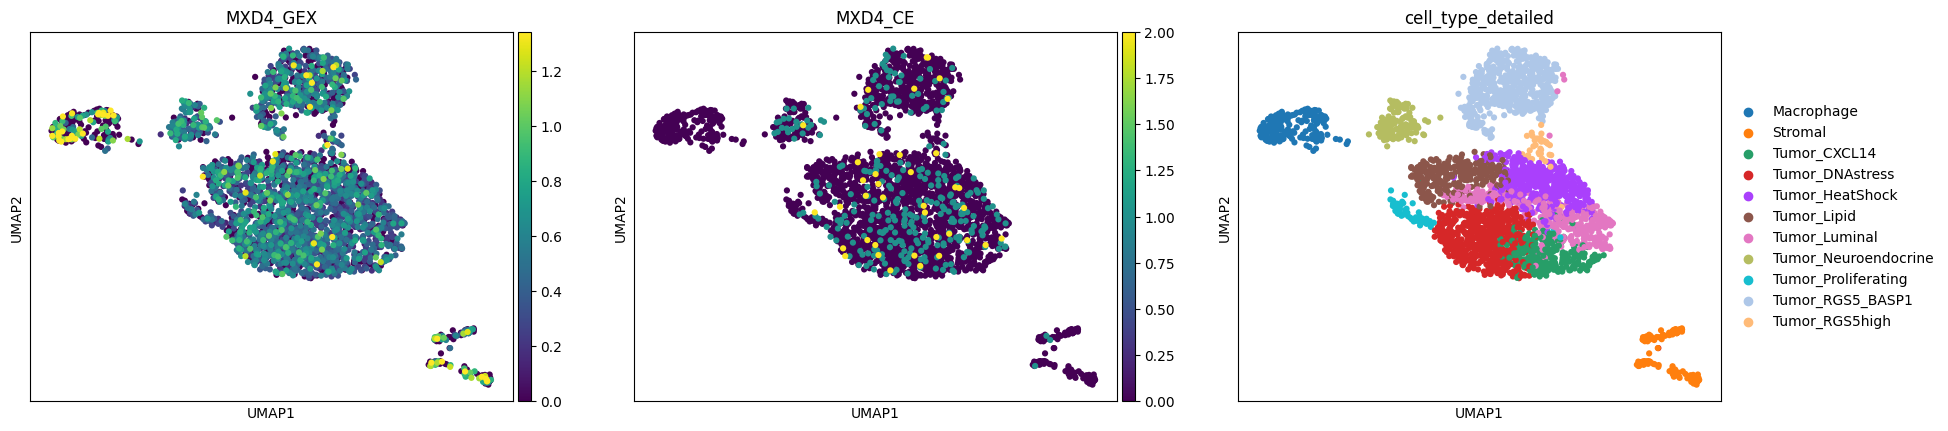

In [197]:
# MXD4 UMAP analysis
mxd4_iso = [f for f in iso_feat_list if f.startswith('MXD4_G')]

# CE signal per cell
mxd4_ce_idx = gene_ce.get('MXD4', [])
mxd4_ce_total = np.array(isocape_mat[:, mxd4_ce_idx].sum(axis=1)).flatten()
adata_gex.obs['MXD4_CE'] = mxd4_ce_total

# GEX
adata_gex.obs['MXD4_GEX'] = adata_gex.raw[:, 'MXD4'].X.toarray().flatten()

# IsoDecipher G-groups
for feat in mxd4_iso:
    idx = iso_feat_list.index(feat)
    adata_gex.obs[feat] = np.array(
        adata_gex.obsm['isoform'][:, idx].todense()).flatten()

# Per CE site
for i in mxd4_ce_idx:
    site = cape_feat_list[i]
    adata_gex.obs[site] = np.array(
        isocape_mat[:, i].todense()).flatten()

sc.pl.umap(adata_gex,
           color=['MXD4_GEX', 'MXD4_CE'] +
               ['cell_type_detailed'],
           ncols=3, vmax='p99',s=80)

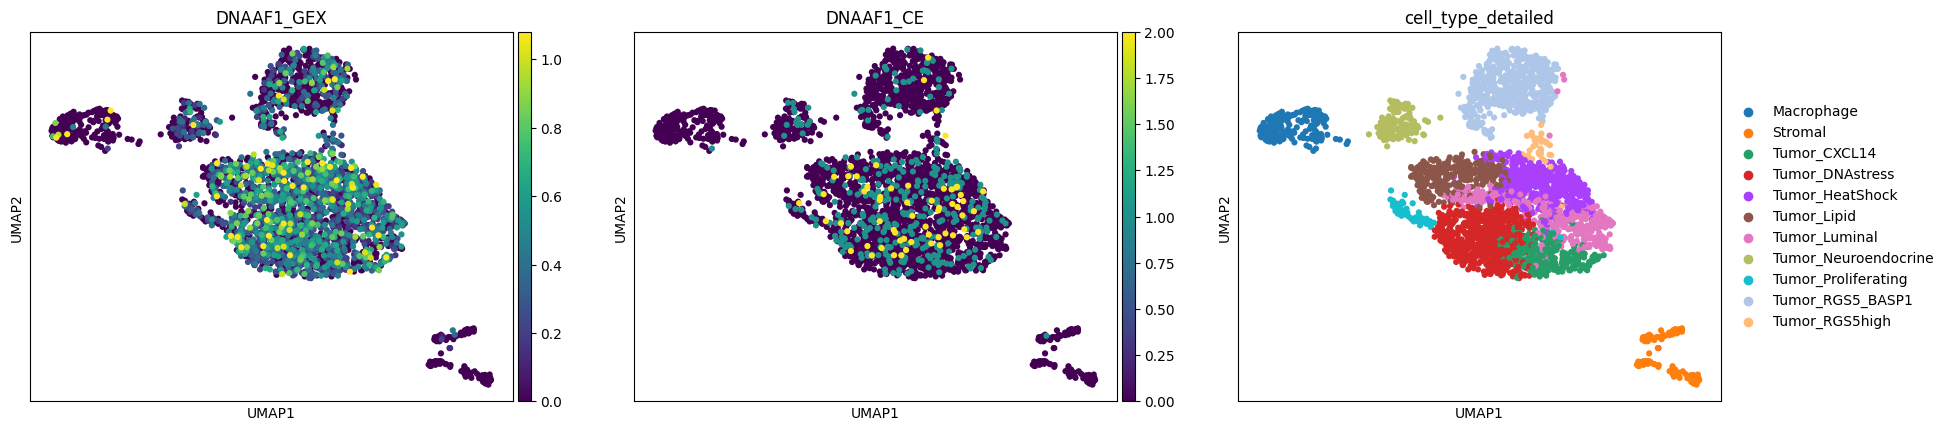

In [203]:
# Sum all DNAAF1 CE sites
dnaaf1_ce_total = np.zeros(adata_gex.n_obs)
for i in gene_ce['DNAAF1']:
    dnaaf1_ce_total += np.array(isocape_mat[:, i].todense()).flatten()

adata_gex.obs['DNAAF1_CE'] = dnaaf1_ce_total

sc.pl.umap(adata_gex,
           color=['DNAAF1_GEX', 'DNAAF1_CE', 'cell_type_detailed'],
           ncols=3, vmax='p99', s=80)

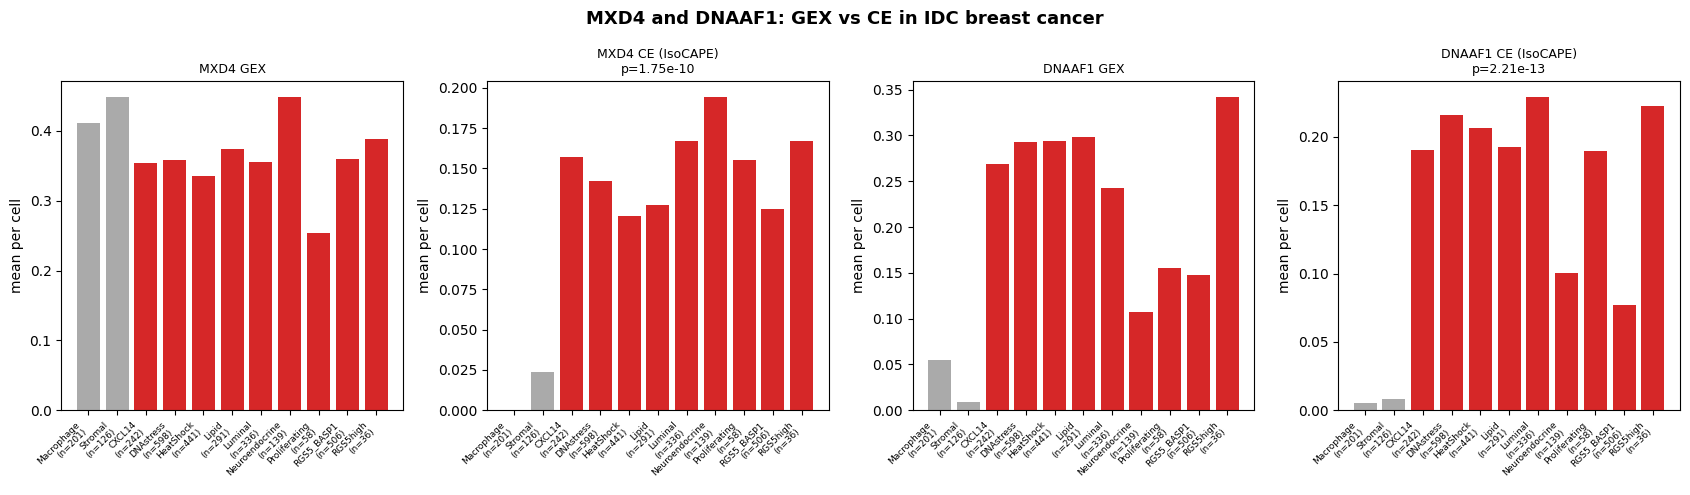

In [207]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

cell_types = sorted(adata_gex.obs['cell_type_detailed'].unique())
n_cells = [(adata_gex.obs['cell_type_detailed']==ct).sum()
           for ct in cell_types]
labels = [f"{ct.replace('Tumor_','')}\n(n={n})"
          for ct, n in zip(cell_types, n_cells)]
x = range(len(cell_types))
colors = ['#d62728' if ct.startswith('Tumor') else '#aaaaaa'
          for ct in cell_types]

plots = [
    ('MXD4',   'MXD4_GEX',   'grey',      'MXD4 GEX'),
    ('MXD4',   None,          'steelblue', 'MXD4 CE (IsoCAPE)'),
    ('DNAAF1', 'DNAAF1_GEX', 'grey',      'DNAAF1 GEX'),
    ('DNAAF1', None,          'steelblue', 'DNAAF1 CE (IsoCAPE)'),
]

for ax, (gene, gex_col, color, title) in zip(axes, plots):
    if gex_col:
        vals = [adata_gex.obs.loc[
                    adata_gex.obs['cell_type_detailed']==ct, gex_col
                ].mean() for ct in cell_types]
        bar_colors = colors
        subtitle = title
    else:
        ce_idx = gene_ce.get(gene, [])
        ce_per_cell = np.array(isocape_mat[:, ce_idx].sum(axis=1)).flatten()
        vals = [ce_per_cell[(adata_gex.obs['cell_type_detailed']==ct).values].mean()
                for ct in cell_types]
        bar_colors = colors
        _, pval = stats.mannwhitneyu(
            ce_per_cell[tumor_mask], ce_per_cell[nontumor_mask],
            alternative='greater')
        subtitle = f'{title}\np={pval:.2e}'

    ax.bar(x, vals, color=bar_colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6.5)
    ax.set_ylabel('mean per cell')
    ax.set_title(subtitle, fontsize=9)

plt.suptitle('MXD4 and DNAAF1: GEX vs CE in IDC breast cancer',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/renegibson/Desktop/MXD4_DNAAF1_barplot.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

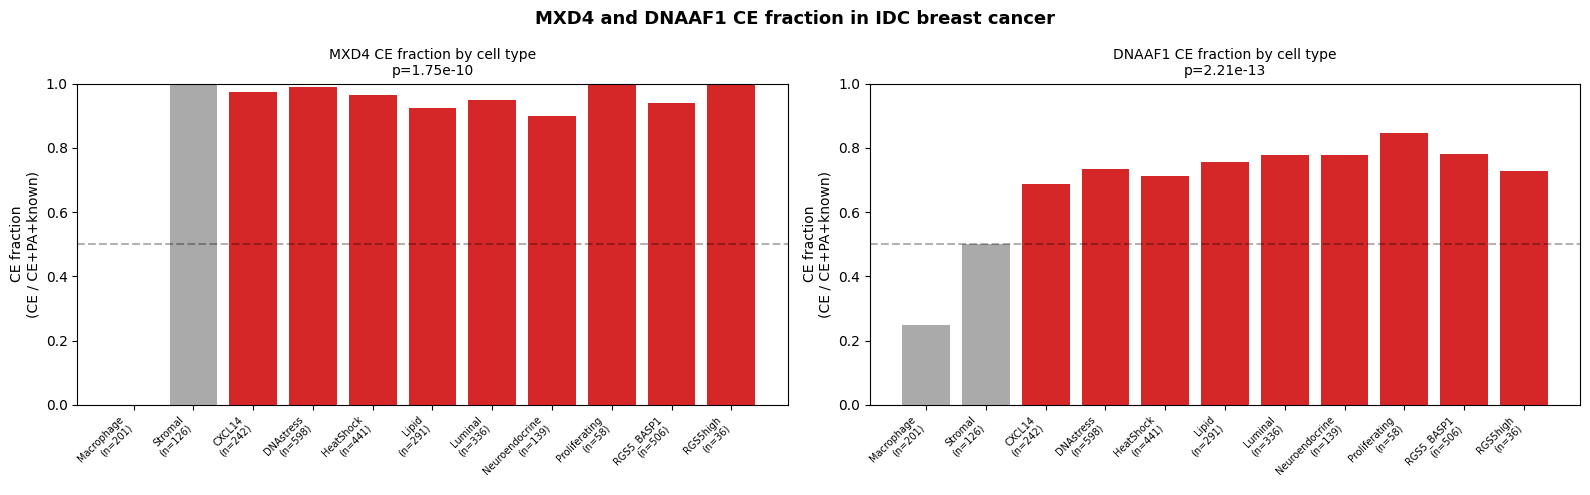

In [204]:
# CE fraction per cell type (CE / CE+PA+known)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cell_types = sorted(adata_gex.obs['cell_type_detailed'].unique())
n_cells = [(adata_gex.obs['cell_type_detailed']==ct).sum()
           for ct in cell_types]
labels = [f"{ct.replace('Tumor_','')}\n(n={n})"
          for ct, n in zip(cell_types, n_cells)]
x = range(len(cell_types))
colors = ['#d62728' if ct.startswith('Tumor') else '#aaaaaa'
          for ct in cell_types]

for ax, gene in zip(axes, ['MXD4', 'DNAAF1']):
    ce_idx = gene_ce.get(gene, [])
    pa_idx = gene_pa.get(gene, [])
    kn_idx = gene_kn.get(gene, [])

    ce_total = np.array(isocape_mat[:, ce_idx].sum(axis=1)).flatten()
    pa_total = np.array(isocape_mat[:, pa_idx].sum(axis=1)).flatten() if pa_idx else np.zeros(adata_gex.n_obs)
    kn_total = np.array(isocape_mat[:, kn_idx].sum(axis=1)).flatten() if kn_idx else np.zeros(adata_gex.n_obs)
    total    = ce_total + pa_total + kn_total

    # Pseudo-bulk fraction per cell type
    fracs = []
    for ct in cell_types:
        mask = (adata_gex.obs['cell_type_detailed']==ct).values
        ce = ce_total[mask].sum()
        pa = pa_total[mask].sum()
        kn = kn_total[mask].sum()
        t  = ce + pa + kn
        fracs.append(ce/t if t > 0 else 0)

    # p-value tumor vs non-tumor
    _, pval = stats.mannwhitneyu(
        ce_total[tumor_mask], ce_total[nontumor_mask],
        alternative='greater')

    ax.bar(x, fracs, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('CE fraction\n(CE / CE+PA+known)')
    ax.set_title(f'{gene} CE fraction by cell type\np={pval:.2e}', fontsize=10)
    ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('MXD4 and DNAAF1 CE fraction in IDC breast cancer',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/renegibson/Desktop/MXD4_DNAAF1_CE_fraction.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

In [189]:
from scipy import stats
import numpy as np

# Pseudo-bulk CE fraction per cell type
# 用CE/(CE+PA+known)而不是raw CE reads

cell_types = sorted(adata_gex.obs['cell_type_detailed'].unique())

for gene, ce_col in [('MXD4', 'MXD4_CE_2254615'), 
                     ('DNAAF1', 'DNAAF1_CE_84173338')]:
    ce_idx = gene_ce.get(gene, [])
    pa_idx = gene_pa.get(gene, [])
    kn_idx = gene_kn.get(gene, [])
    
    # Per cell CE signal
    ce_per_cell = np.array(isocape_mat[:, ce_idx].sum(axis=1)).flatten()
    pa_per_cell = np.array(isocape_mat[:, pa_idx].sum(axis=1)).flatten() if pa_idx else np.zeros(adata_gex.n_obs)
    kn_per_cell = np.array(isocape_mat[:, kn_idx].sum(axis=1)).flatten() if kn_idx else np.zeros(adata_gex.n_obs)
    total = ce_per_cell + pa_per_cell + kn_per_cell
    
    # Kruskal-Wallis across all cell types（non-parametric ANOVA）
    groups = [ce_per_cell[(adata_gex.obs['cell_type_detailed']==ct).values]
              for ct in cell_types]
    stat, pval = stats.kruskal(*groups)
    print(f"\n{gene} CE Kruskal-Wallis: H={stat:.2f}, p={pval:.3e}")
    
    # Tumor vs non-tumor Mann-Whitney
    tumor_vals   = ce_per_cell[tumor_mask]
    nontumor_vals = ce_per_cell[nontumor_mask]
    stat2, pval2 = stats.mannwhitneyu(tumor_vals, nontumor_vals,
                                       alternative='greater')
    print(f"{gene} CE tumor vs non-tumor: p={pval2:.3e}")
    print(f"  tumor mean={tumor_vals.mean():.3f}, "
          f"non-tumor mean={nontumor_vals.mean():.3f}")
    


MXD4 CE Kruskal-Wallis: H=50.65, p=2.023e-07
MXD4 CE tumor vs non-tumor: p=1.753e-10
  tumor mean=0.141, non-tumor mean=0.009

DNAAF1 CE Kruskal-Wallis: H=96.32, p=2.957e-16
DNAAF1 CE tumor vs non-tumor: p=2.209e-13
  tumor mean=0.178, non-tumor mean=0.006


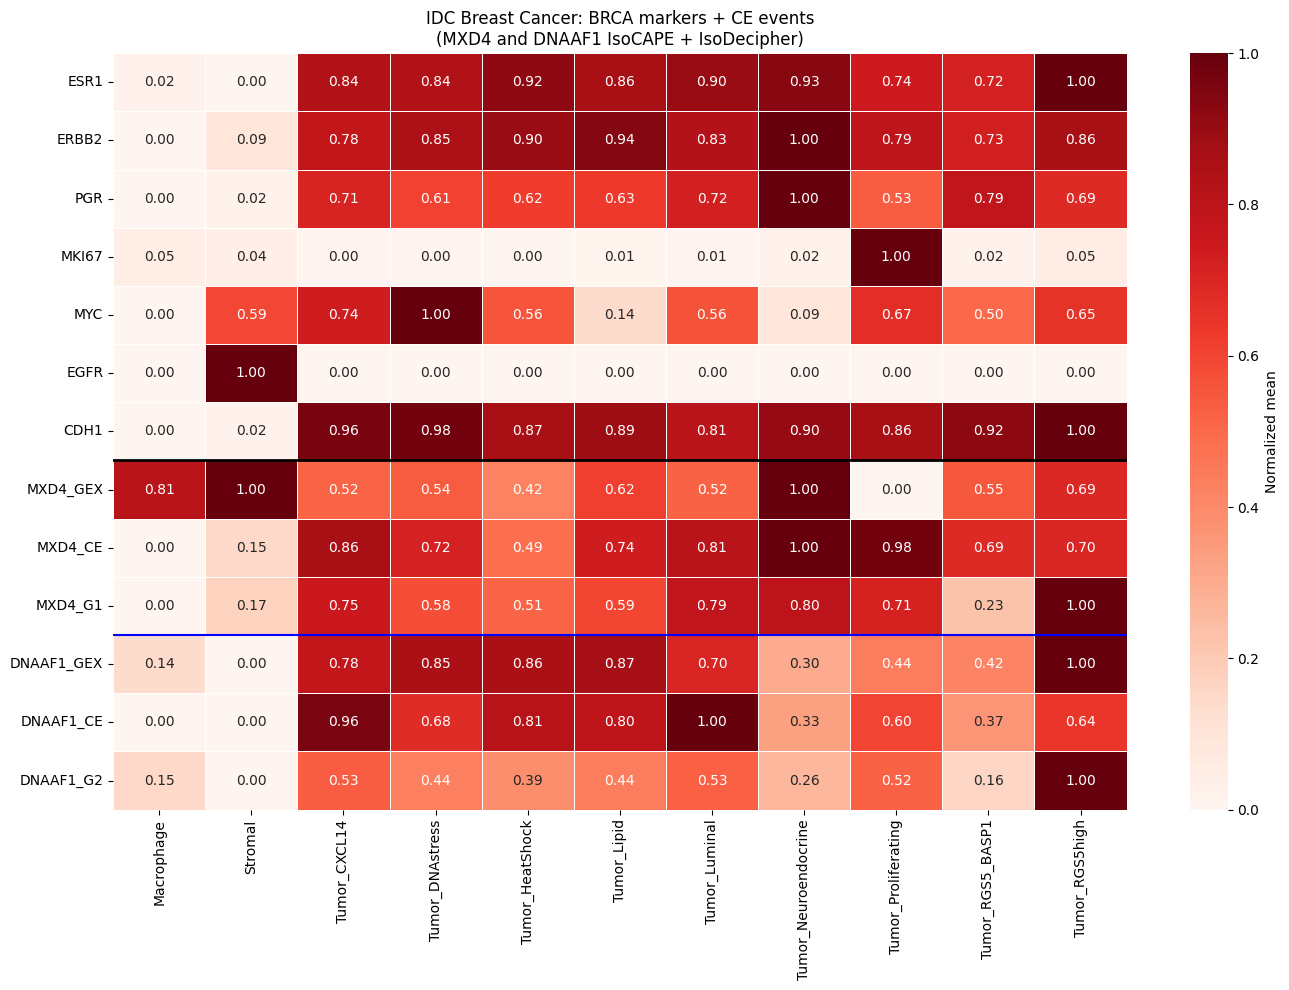

In [188]:
# Add breast cancer genes GEX
brca_genes = ['ESR1', 'ERBB2', 'PGR', 'MKI67', 'MYC', 
              'EGFR', 'CDH1', 'TP53', 'BRCA1', 'PIK3CA']

for gene in brca_genes:
    if gene in adata_gex.var_names:
        adata_gex.obs[f'{gene}_GEX'] = \
            adata_gex.raw[:, gene].X.toarray().flatten()
    else:
        print(f"{gene} not in var_names")

# All features
features = {
    # Breast cancer markers
    'ESR1':    'ESR1_GEX',
    'ERBB2':   'ERBB2_GEX',
    'PGR':     'PGR_GEX',
    'MKI67':   'MKI67_GEX',
    'MYC':     'MYC_GEX',
    'EGFR':    'EGFR_GEX',
    'CDH1':    'CDH1_GEX',
    # MXD4
    'MXD4_GEX':    'MXD4_GEX',
    'MXD4_CE':     'MXD4_CE_2254615',
    'MXD4_G1':     'MXD4_G1',
    # DNAAF1
    'DNAAF1_GEX':  'DNAAF1_GEX',
    'DNAAF1_CE':   'DNAAF1_CE_84173338',
    'DNAAF1_G2':   'DNAAF1_G2',
}

cell_types = sorted(adata_gex.obs['cell_type_detailed'].unique())

# Build matrix
rows = {}
for label, col in features.items():
    if col not in adata_gex.obs.columns:
        print(f"Missing: {col}")
        continue
    rows[label] = [
        adata_gex.obs.loc[
            adata_gex.obs['cell_type_detailed']==ct, col
        ].mean()
        for ct in cell_types
    ]

df_heat = pd.DataFrame(rows, index=cell_types)
df_norm = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min())

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df_norm.T,
            cmap='Reds',
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Normalized mean'})

# Add separator lines
ax.axhline(y=7, color='black', linewidth=2)   # after BRCA markers
ax.axhline(y=10, color='blue', linewidth=1.5)  # after MXD4
ax.set_title('IDC Breast Cancer: BRCA markers + CE events\n'
             '(MXD4 and DNAAF1 IsoCAPE + IsoDecipher)',
             fontsize=12)
plt.tight_layout()
plt.savefig('/Users/renegibson/Desktop/IDC_heatmap.pdf',
            bbox_inches='tight', dpi=150)
plt.show()